## Notebook grammar

Open in Colab: https://colab.research.google.com/github/HNXJ/jaxfne/blob/main/tutorials/jaxfne_neuronal_tensor_first.ipynb

setup -> config -> simulation/probe -> objective cells -> export

This notebook uses package APIs through `import jaxfne as jtfne`; editable inputs are centralized in config cells; readouts are proxy-scoped where named as proxies; exports use JSON/PNG receipts when artifacts are produced.

# jaxfne: NeuronalTensor-first Workflow

Demonstrates the 0.4.7 tensor-first circuit-definition path: build a declarative
`Areas x Layers x NeuronTypes` `NeuronalTensor`, save/reload it as JSON, construct
and simulate it, then enable **HDP homeostatic plasticity** (synaptic + per-cell-type
H-factor adaptation, cube-law time constant) via an explicit `RuntimeConfig` override
-- with zero new public API.

## Scope Gates
- **run_status:** `tutorial_scaffold`
- **model_status:** `computational_scaffold`
- **field_solver_status:** `linear_solver`
- **amplitude_status:** `False`

`Configuration` (the original builder) and `NeuronalTensor` (this notebook) both
converge on the same `Model` via `construct()` -- see
[Configuration Grammar](../docs/guides/configuration_grammar.md) for the comparison.

## Setup: Installation & Environment

In [1]:
# Colab-compatible setup: use local checkout when available; otherwise install jaxfne from current main.
import importlib.util, subprocess, sys
from pathlib import Path
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "jaxfne").is_dir() and (_candidate / "pyproject.toml").exists():
        sys.path.insert(0, str(_candidate))
        break
if importlib.util.find_spec("jaxfne") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "jaxfne[viz,opt] @ git+https://github.com/HNXJ/jaxfne.git@main"])


In [2]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import jaxfne as jtfne
print(f"jaxfne version: {jtfne.__version__}")


jaxfne version: 0.4.4


## Outline

1. **Define:** build a `NeuronalTensor` (Areas/Layers/NeuronTypes), save/reload as JSON
2. **Construct + simulate:** baseline run via `RuntimeConfiguration`
3. **HDP:** enable homeostatic plasticity via an explicit `RuntimeConfig` override
4. **Visualize:** raster via `jaxfne.vis` (no matplotlib outside the package boundary)
5. **Export:** JSON manifest receipt

## 1. Define the circuit

In [3]:
SEED = 0
DURATION_MS = 1000.0
DT_MS = 0.5

E  = jtfne.NeuronType.make("E", fraction=0.9)   # explicit population fraction
PV = jtfne.NeuronType.make("PV", fraction=0.1)  # (omit fraction on any type in a layer -> even split)
L4 = jtfne.Layer(name="L4", n_neurons=100, neuron_types=[E, PV])
v1 = jtfne.Area(name="V1", layers=[L4])
tensor = jtfne.NeuronalTensor(areas=[v1], name="tutorial_tensor_first")

Path("tutorial_outputs").mkdir(exist_ok=True)
manifest_path = Path("tutorial_outputs/tutorial_tensor_first.json")
jtfne.save_neuronal_tensor(tensor, manifest_path)
tensor = jtfne.load_neuronal_tensor(manifest_path)
print("areas:", len(tensor.areas), "layers:", len(tensor.areas[0].layers))


areas: 1 layers: 1


## 2. Construct + baseline simulate

In [4]:
model = jtfne.construct(tensor, jtfne.RuntimeConfiguration(seed=SEED, duration_ms=DURATION_MS, dt_ms=DT_MS))
signals = jtfne.simulate(model, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED)
spk = signals.get("spk")
rate_hz = float(spk.mean() * (1000.0 / DT_MS))
print("baseline mean rate (Hz):", rate_hz)


baseline mean rate (Hz): 9.979999542236328


## 3. Enable HDP homeostatic plasticity

`RuntimeConfiguration` (the tensor path's runtime object, used above) has **no** HDP
field. `RuntimeConfig` (the legacy/general runtime object) does. Passing an explicit
`runtime=RuntimeConfig(enable_hdp=True, ...)` to `simulate()` overrides any
`Configuration`-derived metadata entirely -- this is how HDP runs on a tensor-built
`Model` with zero new public API. Time constant is cube-law:
`tau_i = tau_0_ms * size_i**3` (a `relative_size=2.0` neuron integrates `H` 8x slower
than `relative_size=1.0`).

In [5]:
runtime_hdp = jtfne.RuntimeConfig(enable_hdp=True, hdp_params={
    "K_HDP": 0.01, "tau_0_ms": 200.0, "K_ctrl": 5.0,
    "size_scale_by_cell_type": {"E": 2.0, "PV": 1.0},   # tau_i = tau_0_ms * size_i**3
})
signals = jtfne.simulate(model, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED, runtime=runtime_hdp)
diag = model.last_hdp_diagnostics()
H_trace = np.asarray(diag["H_trace"])
print("H_trace shape:", H_trace.shape, "H final mean:", float(H_trace[-1].mean()))


H_trace shape: (2000, 100) H final mean: 1.0


## 4. Visualize (via `jaxfne.vis` only)

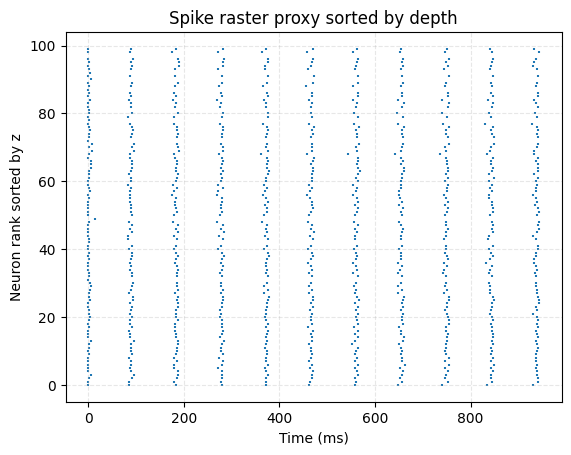

In [6]:
fig = jtfne.vis.raster(signals)
fig.savefig("tutorial_outputs/tutorial_tensor_first_raster.png", dpi=80)
plt.show()


## 5. Export manifest receipt

In [7]:
m = model.manifest(signals=signals)
json.dump(m, open("tutorial_outputs/tutorial_tensor_first_manifest.json", "w"), indent=2, allow_nan=False)
print("manifest keys:", list(m.keys())[:8])


manifest keys: ['package', 'manifest_schema_version', 'claim_level', 'source_calibration_status', 'source_projection_mode', 'source_decomposition', 'boundary_condition', 'gauge']


## Why this matters

`NeuronalTensor` is not a replacement for `Configuration` -- it's a second,
declarative on-ramp into the same `construct()` -> `simulate()` -> probe/objective/
manifest chain, suited to explicit JSON-round-trippable circuit definitions and to
HDP homeostatic plasticity. See also:

- [NeuronalTensor API reference](../docs/api/neuronal_tensor.md)
- [HDP guide](../docs/guides/hdp.md) -- the full control law and tuned presets
- [Configuration Grammar](../docs/guides/configuration_grammar.md) -- the other on-ramp
- [examples/08_neuronal_tensor_first.py](../examples/08_neuronal_tensor_first.py) -- a standalone script version of this notebook